# EDA cho bai toan du bao generation_TWh (TFT)

Notebook nay tap trung EDA du lieu truoc khi tiep tuc tune tham so mo hinh:
- Kiem tra chat luong du lieu (thieu, trung lap, bao phu thoi gian)
- Kiem tra phan phoi target va outlier theo tung nhom
- Danh gia rui ro leak (Total Generation)
- Phan tich quan he voi bien thoi tiet
- De xuat tien xu ly toi uu cho TFT

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 160)
sns.set_theme(style='whitegrid')

In [4]:
from pathlib import Path

candidate_paths = [
    Path('data/raw/ember_data/all_country_data_cleaned_merged.csv'),
    Path('../data/raw/ember_data/all_country_data_cleaned_merged.csv'),
    Path('../../data/raw/ember_data/all_country_data_cleaned_merged.csv'),
]

DATA_PATH = None
for p in candidate_paths:
    if p.exists():
        DATA_PATH = p
        break

if DATA_PATH is None:
    raise FileNotFoundError('Khong tim thay file all_country_data_cleaned_merged.csv tu notebook hien tai.')

df = pd.read_csv(DATA_PATH)
print('Loaded from:', DATA_PATH)
print('Shape:', df.shape)
print('Columns:', list(df.columns))
df.head()

Loaded from: ..\data\raw\ember_data\all_country_data_cleaned_merged.csv
Shape: (10513, 9)
Columns: ['entity', 'entity code', 'date', 'series', 'generation_TWh', 'precipitation', 'solar', 'humidity', 'temperature']


,entity,entity code,date,series,generation_TWh,precipitation,solar,humidity,temperature
0,Argentina,ARG,01/01/2018,Bioenergy,0.02,10648.72,24.537102,9.435314,18.193195
1,Argentina,ARG,01/01/2018,Coal,0.26,10648.72,24.537102,9.435314,18.193195
2,Argentina,ARG,01/01/2018,Gas,7.79,10648.72,24.537102,9.435314,18.193195
3,Argentina,ARG,01/01/2018,Hydro,3.69,10648.72,24.537102,9.435314,18.193195
4,Argentina,ARG,01/01/2018,Nuclear,0.64,10648.72,24.537102,9.435314,18.193195


In [5]:
eda = df.copy()
eda.columns = [c.strip() for c in eda.columns]
eda['date'] = pd.to_datetime(eda['date'], dayfirst=True, errors='coerce')
eda['series'] = eda['series'].astype(str).str.strip()
eda['generation_TWh'] = pd.to_numeric(eda['generation_TWh'], errors='coerce')
for c in ['precipitation', 'solar', 'humidity', 'temperature']:
    if c in eda.columns:
        eda[c] = pd.to_numeric(eda[c], errors='coerce')

print('Date min/max:', eda['date'].min(), '->', eda['date'].max())
print('Countries:', eda['entity'].nunique())
print('Series:', eda['series'].nunique())
print('Has Total Generation:', bool(eda['series'].str.casefold().eq('total generation').any()))

Date min/max: 2018-01-01 00:00:00 -> 2025-12-01 00:00:00
Countries: 14
Series: 10
Has Total Generation: True


In [6]:
# 1) Chat luong du lieu
missing_ratio = (eda.isna().mean() * 100).sort_values(ascending=False).to_frame('missing_pct')
dup_count = eda.duplicated(subset=['entity', 'series', 'date']).sum()

print('So dong trung lap (entity, series, date):', int(dup_count))
display(missing_ratio)

So dong trung lap (entity, series, date): 0


,missing_pct
entity,0.0
entity code,0.0
date,0.0
series,0.0
generation_TWh,0.0
precipitation,0.0
solar,0.0
humidity,0.0
temperature,0.0


In [7]:
# 2) So sanh truoc/sau khi loai Total Generation
raw_rows = len(eda)
no_total = eda[~eda['series'].str.casefold().eq('total generation')].copy()

print('Rows raw:', raw_rows)
print('Rows no-total:', len(no_total))
print('Rows removed:', raw_rows - len(no_total))

summary_cmp = pd.DataFrame({
    'dataset': ['raw', 'no_total'],
    'rows': [len(eda), len(no_total)],
    'countries': [eda['entity'].nunique(), no_total['entity'].nunique()],
    'series': [eda['series'].nunique(), no_total['series'].nunique()]
})
display(summary_cmp)

Rows raw: 10513
Rows no-total: 9274
Rows removed: 1239


,dataset,rows,countries,series
0,raw,10513,14,10
1,no_total,9274,14,9


Target quantiles: {0.5: 0.75, 0.9: 6.88, 0.95: 12.917, 0.99: 40.9478}


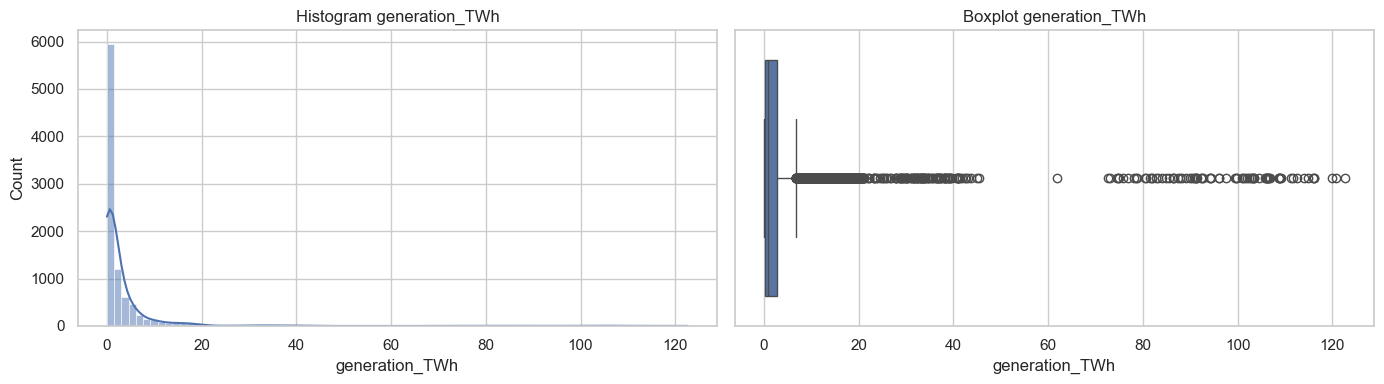

In [8]:
# 3) Phan phoi target va lech cuc doan
target = no_total['generation_TWh'].dropna()
q = target.quantile([0.5, 0.9, 0.95, 0.99]).to_dict()

print('Target quantiles:', {k: round(v, 4) for k, v in q.items()})

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(target, bins=80, kde=True, ax=axes[0])
axes[0].set_title('Histogram generation_TWh')
axes[0].set_xlabel('generation_TWh')

sns.boxplot(x=target, ax=axes[1])
axes[1].set_title('Boxplot generation_TWh')
axes[1].set_xlabel('generation_TWh')
plt.tight_layout()
plt.show()

count    105.000000
mean      88.323810
std        6.197852
min       63.000000
10%       82.000000
25%       83.000000
50%       91.000000
75%       95.000000
90%       95.000000
max       96.000000
Name: n_months, dtype: float64


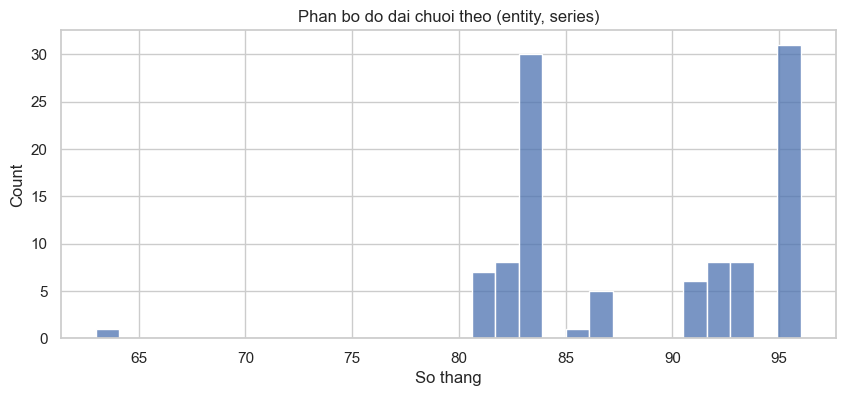

,entity,series,n_months
28,Egypt,Bioenergy,63
92,Thailand,Hydro,81
93,Thailand,Other Fossil,81
95,Thailand,Wind,81
90,Thailand,Coal,81
91,Thailand,Gas,81
89,Thailand,Bioenergy,81
94,Thailand,Solar,81
64,Pakistan,Solar,82
59,Pakistan,Coal,82


In [9]:
# 4) Bao phu chuoi thoi gian theo nhom
group_len = no_total.dropna(subset=['date']).groupby(['entity', 'series'])['date'].nunique().reset_index(name='n_months')

print(group_len['n_months'].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]))

plt.figure(figsize=(10, 4))
sns.histplot(group_len['n_months'], bins=30)
plt.title('Phan bo do dai chuoi theo (entity, series)')
plt.xlabel('So thang')
plt.show()

display(group_len.sort_values('n_months').head(15))

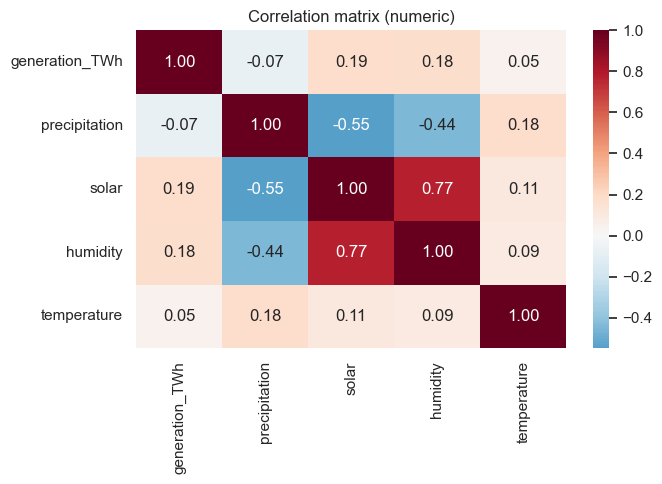

In [10]:
# 5) Quan he target voi bien thoi tiet
num_cols = ['generation_TWh', 'precipitation', 'solar', 'humidity', 'temperature']
num_cols = [c for c in num_cols if c in no_total.columns]
corr = no_total[num_cols].corr(numeric_only=True)

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0)
plt.title('Correlation matrix (numeric)')
plt.tight_layout()
plt.show()

In [11]:
# 6) Top nhom co bien dong lon nhat (de uu tien mo hinh hoa)
vol = no_total.groupby(['entity', 'series'])['generation_TWh'].agg(['mean', 'std', 'max']).reset_index()
vol['cv'] = vol['std'] / vol['mean'].replace(0, np.nan)
vol = vol.replace([np.inf, -np.inf], np.nan).dropna(subset=['cv'])
display(vol.sort_values('cv', ascending=False).head(20))

,entity,series,mean,std,max,cv
67,Peru,Coal,0.002169,0.007333,0.06,3.381428
21,Colombia,Bioenergy,0.002747,0.008952,0.05,3.258695
70,Peru,Other Fossil,0.021084,0.052476,0.35,2.488842
26,Colombia,Solar,0.088571,0.116071,0.37,1.310474
93,Thailand,Other Fossil,0.067531,0.083569,0.33,1.237498
63,Pakistan,Other Fossil,0.475610,0.519846,1.83,1.093009
49,Mexico,Bioenergy,0.006988,0.007609,0.02,1.088810
28,Egypt,Bioenergy,0.004762,0.005034,0.01,1.057233
83,South Africa,Hydro,0.123763,0.119300,0.43,0.963933
12,Bangladesh,Solar,0.046506,0.042725,0.15,0.918704


In [12]:
# 7) Goi y toi uu du lieu truoc khi tune tham so
recommendations = [
    '1. Giu bo loc loai series Total Generation (tranh leak).',
    '2. Khong clip manh target toan cuc; neu can thi chi winsor theo nhom va nhe (0.5%-99.5%).',
    '3. Chuan hoa/transform target theo nhom (GroupNormalizer) va can nhac log transform cho nhom lech manh.',
    '4. Tach rieng cac nhom co CV qua cao de train rieng hoac gan trong so cao hon.',
    '5. Kiem tra chuoi ngan (n_months thap), co the bo qua hoac giam horizon cho nhom do.',
    '6. Them feature su kien theo mua/nam va rolling stats (3, 6, 12 thang) truoc khi tune hyper-params.',
    '7. Danh gia chat luong tren cac quantile (low/mid/high) thay vi chi nhin metric tong hop.'
]
print('Goi y EDA -> Data-centric optimization:')
for r in recommendations:
    print('-', r)

Goi y EDA -> Data-centric optimization:
- 1. Giu bo loc loai series Total Generation (tranh leak).
- 2. Khong clip manh target toan cuc; neu can thi chi winsor theo nhom va nhe (0.5%-99.5%).
- 3. Chuan hoa/transform target theo nhom (GroupNormalizer) va can nhac log transform cho nhom lech manh.
- 4. Tach rieng cac nhom co CV qua cao de train rieng hoac gan trong so cao hon.
- 5. Kiem tra chuoi ngan (n_months thap), co the bo qua hoac giam horizon cho nhom do.
- 6. Them feature su kien theo mua/nam va rolling stats (3, 6, 12 thang) truoc khi tune hyper-params.
- 7. Danh gia chat luong tren cac quantile (low/mid/high) thay vi chi nhin metric tong hop.


In [14]:
# 9) Luu pre-model dataset
out_path = Path('../data/processed/tft_premodel_dataset.csv')
out_path.parent.mkdir(parents=True, exist_ok=True)
premodel.to_csv(out_path, index=False)
print('Saved:', out_path.resolve())
print('Rows:', len(premodel), '| Groups:', premodel[['entity', 'series']].drop_duplicates().shape[0])

Saved: D:\WorkSpace\Study\NCKH\data\processed\tft_premodel_dataset.csv
Rows: 9274 | Groups: 105


In [13]:
# 8) Tao pre-model dataset
from pathlib import Path

premodel = no_total.copy()
premodel = premodel.drop_duplicates(subset=['entity', 'series', 'date'], keep='last').copy()
premodel = premodel.dropna(subset=['date', 'generation_TWh', 'entity', 'series']).copy()
premodel['generation_TWh'] = premodel['generation_TWh'].clip(lower=0)

weather_cols = [c for c in ['precipitation', 'solar', 'humidity', 'temperature'] if c in premodel.columns]
group_cols = ['entity', 'series']

for c in weather_cols:
    premodel[c] = premodel.groupby(group_cols)[c].transform(lambda s: s.ffill().bfill())
    premodel[c] = premodel[c].fillna(premodel[c].median())

# Winsor nhe cho weather de giam outlier manh
for c in weather_cols:
    low = premodel.groupby(group_cols)[c].transform(lambda s: s.quantile(0.005))
    high = premodel.groupby(group_cols)[c].transform(lambda s: s.quantile(0.995))
    premodel[c] = premodel[c].clip(lower=low, upper=high)

premodel = premodel.sort_values(group_cols + ['date']).reset_index(drop=True)

# Tao chi so thoi gian
premodel['date'] = premodel['date'].dt.to_period('M').dt.to_timestamp()
min_date = premodel['date'].min()
premodel['time_idx'] = ((premodel['date'].dt.year - min_date.year) * 12 + (premodel['date'].dt.month - min_date.month)).astype(int)

# Feature mua vu
premodel['month_num'] = premodel['date'].dt.month.astype(int)
premodel['month'] = premodel['month_num'].astype(str)
premodel['month_sin'] = np.sin(2 * np.pi * premodel['month_num'] / 12.0)
premodel['month_cos'] = np.cos(2 * np.pi * premodel['month_num'] / 12.0)

# Lag/rolling chi dung qua khu (shift truoc khi rolling)
for lag in [1, 3, 6, 12]:
    premodel[f'target_lag_{lag}'] = premodel.groupby(group_cols)['generation_TWh'].shift(lag)

for w in [3, 6, 12]:
    shifted = premodel.groupby(group_cols)['generation_TWh'].shift(1)
    premodel[f'target_roll_mean_{w}'] = shifted.groupby([premodel['entity'], premodel['series']]).transform(lambda s: s.rolling(w, min_periods=1).mean())
    premodel[f'target_roll_std_{w}'] = shifted.groupby([premodel['entity'], premodel['series']]).transform(lambda s: s.rolling(w, min_periods=2).std())

fill_cols = [c for c in premodel.columns if c.startswith('target_lag_') or c.startswith('target_roll_')]
for c in fill_cols:
    premodel[c] = premodel.groupby(group_cols)[c].transform(lambda s: s.ffill().bfill())
    premodel[c] = premodel[c].fillna(0.0)

# Trong so cho metric phu tro
premodel['sample_weight'] = np.sqrt(1.0 + premodel['generation_TWh'])

print('Premodel shape:', premodel.shape)
print('Premodel columns:', len(premodel.columns))
premodel.head()

Premodel shape: (9274, 25)
Premodel columns: 25


,entity,entity code,date,series,generation_TWh,precipitation,solar,humidity,temperature,time_idx,month_num,month,month_sin,month_cos,target_lag_1,target_lag_3,target_lag_6,target_lag_12,target_roll_mean_3,target_roll_std_3,target_roll_mean_6,target_roll_std_6,target_roll_mean_12,target_roll_std_12,sample_weight
0,Argentina,ARG,2018-01-01,Bioenergy,0.02,10648.72,24.537102,9.435314,18.193195,0,1,1,0.500000,8.660254e-01,0.02,0.02,0.02,0.02,0.02,0.0,0.02,0.0,0.02,0.0,1.009950
1,Argentina,ARG,2018-02-01,Bioenergy,0.02,6886.61,22.315455,9.437452,18.337836,1,2,2,0.866025,5.000000e-01,0.02,0.02,0.02,0.02,0.02,0.0,0.02,0.0,0.02,0.0,1.009950
2,Argentina,ARG,2018-03-01,Bioenergy,0.02,8798.65,18.051761,8.606008,16.500330,2,3,3,1.000000,6.123234e-17,0.02,0.02,0.02,0.02,0.02,0.0,0.02,0.0,0.02,0.0,1.009950
3,Argentina,ARG,2018-04-01,Bioenergy,0.02,8490.94,12.733422,8.454025,15.133189,3,4,4,0.866025,-5.000000e-01,0.02,0.02,0.02,0.02,0.02,0.0,0.02,0.0,0.02,0.0,1.009950
4,Argentina,ARG,2018-05-01,Bioenergy,0.03,8964.45,8.799104,7.130631,11.819865,4,5,5,0.500000,-8.660254e-01,0.02,0.02,0.02,0.02,0.02,0.0,0.02,0.0,0.02,0.0,1.014889


## Pre-model Dataset Builder
Xay dung bo du lieu train-ready cho TFT tu EDA findings:
- Loai bo Total Generation
- Chuan hoa thoi gian theo thang
- Fill missing weather theo nhom
- Winsor nhe cho weather theo nhom
- Tao feature lag va rolling theo nhom (khong leak)
- Luu ra data/processed/tft_premodel_dataset.csv

In [15]:
# 9) Xuất pre-model dataset ra để train
import os

out_dir = Path('../data/processed')
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / 'tft_premodel_dataset.csv'

premodel.to_csv(out_path, index=False)
print(f"Bảng tóm tắt đã lưu thành công tại {out_path} ({os.path.getsize(out_path) / 1024 / 1024:.2f} MB)")


Bảng tóm tắt đã lưu thành công tại ..\data\processed\tft_premodel_dataset.csv (2.33 MB)
